In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.offline as py
import numpy as np
py.init_notebook_mode(connected = True)
sns.set_style('darkgrid')
plt.style.use('dark_background')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model    import LinearRegression, BayesianRidge
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.neighbors       import KNeighborsRegressor
from xgboost                 import XGBRegressor
from lightgbm                import LGBMRegressor
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [2]:
# Load data
df = pd.read_csv('dataset/final_data.csv')
df

,Year,Precipitation,Specific Humidity,Avg. Temp,Min Temp,Max Temp,Surface Pressure,Wind Speed,Relative Humidity,Dew Point,Cloud Amount,Pesticides,NDVI_season_mean,NDVI_season_max,NDVI_season_sum,Item,Yield
0,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Apples,11284.2
1,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Grapes,14023.7
2,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Maize (corn),8000.0
3,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Potatoes,33604.3
4,2000,1012.36,6.612240,8.686993,-10.24,27.48,96.742500,3.084190,87.379482,6.468003,0.745564,2.45,0.488564,0.684710,5.862769,Wheat,5576.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,2022,744.55,6.396865,10.210698,-9.13,35.82,96.947566,2.854618,79.424750,6.040408,0.655350,1.84,0.312239,0.474614,3.746867,Apples,13800.0
111,2022,744.55,6.396865,10.210698,-9.13,35.82,96.947566,2.854618,79.424750,6.040408,0.655350,1.84,0.312239,0.474614,3.746867,Grapes,9680.3
112,2022,744.55,6.396865,10.210698,-9.13,35.82,96.947566,2.854618,79.424750,6.040408,0.655350,1.84,0.312239,0.474614,3.746867,Maize (corn),5055.6
113,2022,744.55,6.396865,10.210698,-9.13,35.82,96.947566,2.854618,79.424750,6.040408,0.655350,1.84,0.312239,0.474614,3.746867,Potatoes,22828.1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               115 non-null    int64  
 1   Precipitation      115 non-null    float64
 2   Specific Humidity  115 non-null    float64
 3   Avg. Temp          115 non-null    float64
 4   Min Temp           115 non-null    float64
 5   Max Temp           115 non-null    float64
 6   Surface Pressure   115 non-null    float64
 7   Wind Speed         115 non-null    float64
 8   Relative Humidity  115 non-null    float64
 9   Dew Point          115 non-null    float64
 10  Cloud Amount       115 non-null    float64
 11  Pesticides         115 non-null    float64
 12  NDVI_season_mean   115 non-null    float64
 13  NDVI_season_max    115 non-null    float64
 14  NDVI_season_sum    115 non-null    float64
 15  Item               115 non-null    object 
 16  Yield              115 non

In [4]:
df.describe()

,Year,Precipitation,Specific Humidity,Avg. Temp,Min Temp,Max Temp,Surface Pressure,Wind Speed,Relative Humidity,Dew Point,Cloud Amount,Pesticides,NDVI_season_mean,NDVI_season_max,NDVI_season_sum,Yield
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,2011.000000,841.232609,6.345881,8.635798,-11.827826,31.725652,96.820361,2.928410,84.302939,5.702602,0.694838,2.457826,0.485884,0.679498,5.830608,12969.207826
std,6.662279,110.770776,0.185240,0.752582,3.393310,3.101486,0.109374,0.111617,2.414910,0.540979,0.030152,0.305720,0.042282,0.050326,0.507384,9243.854840
min,2000.000000,683.510000,5.869064,6.970481,-20.500000,26.740000,96.554899,2.777561,79.424750,4.166736,0.615799,1.840000,0.312239,0.474614,3.746867,3681.600000
25%,2005.000000,727.680000,6.220906,8.103744,-14.170000,29.440000,96.750220,2.834976,83.058651,5.495547,0.681899,2.310000,0.476240,0.669287,5.714881,6235.650000
50%,2011.000000,813.390000,6.336496,8.605842,-10.620000,31.770000,96.821946,2.908163,84.812591,5.785161,0.690161,2.450000,0.495553,0.685987,5.946640,9098.700000
75%,2017.000000,929.830000,6.463798,8.973929,-9.190000,33.670000,96.907615,2.998577,86.614580,5.996730,0.717972,2.490000,0.509433,0.694072,6.113194,14705.250000
max,2022.000000,1045.300000,6.652249,10.210698,-5.160000,38.620000,97.026886,3.148360,87.379482,6.669198,0.745564,3.210000,0.527623,0.746139,6.331479,36019.900000


<function matplotlib.pyplot.show(close=None, block=None)>

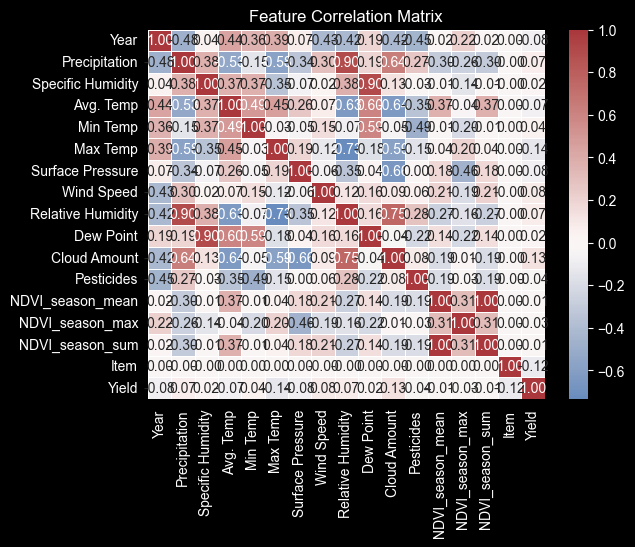

In [5]:
# Correlation matrix
from sklearn.preprocessing import LabelEncoder

df1 = df.copy()
label_encoder = LabelEncoder()

for col in df1:
    df1[col] = label_encoder.fit_transform(df1[col])
    
cm = sns.heatmap(
    df1.corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=.5
)
plt.title("Feature Correlation Matrix")
plt.show

In [6]:
# Define models
models = [
    ("Linear Regression",    LinearRegression()),
    ("Decision Tree",        DecisionTreeRegressor(random_state=1)),
    ("Random Forest",        RandomForestRegressor(n_estimators = 1000, random_state=1)),
    ("Gradient Boosting",    GradientBoostingRegressor(random_state=1)),
    ("XGBoost",              XGBRegressor(random_state=1)),
    ("LightGBM",             LGBMRegressor(random_state=1, verbosity=-1)),
    ("KNN",                  KNeighborsRegressor(n_neighbors=10)),
    ("Bayesian Ridge",       BayesianRidge()),
]

In [7]:
# Split into X, y
y = df['Yield']
X = df.drop(columns=['Yield'])
X = pd.get_dummies(X)

# Train/test split: data from 2000-2017 is used for training while the one from 2018-2022 is for testing
x_train, x_test, y_train, y_test = X.iloc[0:18*5], X.iloc[18*5:], y.iloc[0:18*5], y.iloc[18*5:]

In [8]:
# Training and evaluation
results = []
for name, model in models:
    print(f"\n>>> Training & evaluating: {name}")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    print(f"  MSE = {mse:.2f},  R² = {r2:.3f}")
    results.append((name, mse, r2))


>>> Training & evaluating: Linear Regression
  MSE = 24277032.75,  R² = 0.561

>>> Training & evaluating: Decision Tree
  MSE = 10951808.93,  R² = 0.802

>>> Training & evaluating: Random Forest
  MSE = 10690283.06,  R² = 0.807

>>> Training & evaluating: Gradient Boosting
  MSE = 11801823.71,  R² = 0.787

>>> Training & evaluating: XGBoost
  MSE = 10975142.70,  R² = 0.802

>>> Training & evaluating: LightGBM
  MSE = 56185003.41,  R² = -0.016

>>> Training & evaluating: KNN
  MSE = 53951425.90,  R² = 0.025

>>> Training & evaluating: Bayesian Ridge
  MSE = 57781428.69,  R² = -0.045


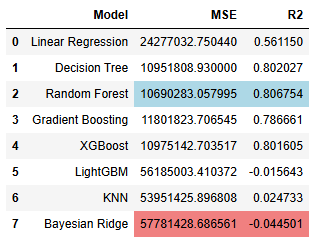

In [10]:
# Comparing models
from IPython.display import Image
summary = pd.DataFrame(results, columns = ['Model', 'MSE', 'R2'])
summary_format =  (
    summary.style
    .highlight_max(subset = ['R2'], color='lightblue')
    .highlight_min(subset=['MSE'], color='lightblue')
    .highlight_max(subset=['MSE'], color='lightcoral')
    .highlight_min(subset=['R2'], color='lightcoral')
)
# display(summary_format)
display(Image('images/summary_format.png'))

Among the considered methods, Random Forest brings the best performance with the lowest MSE (~ 10.7 million) and highest R² (0.81), followed by Decision Tree (MSE ≈ 10.95 million, R² ≈ 0.8) and XGBoost (MSE ≈ 10.97 million, R² ≈ 0.8).